In [1]:
import pandas as pd
file_path = r'C:\Users\pande\MoodFlix\TMDB_movie_dataset_v11.csv'
df = pd.read_csv(file_path)

In [2]:
len(df)

1385673

In [3]:
df.columns

Index(['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'tagline', 'genres',
       'production_companies', 'production_countries', 'spoken_languages',
       'keywords'],
      dtype='object')

In [4]:
len(df.columns)

24

In [5]:
cols = [
    "title",
    "genres",
    "keywords",
    "overview",
    "vote_average",
    "vote_count"
]

df = df[cols]

In [6]:
df.columns

Index(['title', 'genres', 'keywords', 'overview', 'vote_average',
       'vote_count'],
      dtype='object')

In [7]:
len(df.columns)

6

In [8]:
df.head()

,title,genres,keywords,overview,vote_average,vote_count
0,Inception,"Action, Science Fiction, Adventure","rescue, mission, dream, airplane, paris, franc...","Cobb, a skilled thief who commits corporate es...",8.364,34495
1,Interstellar,"Adventure, Drama, Science Fiction","rescue, future, spacecraft, race against time,...",The adventures of a group of explorers who mak...,8.417,32571
2,The Dark Knight,"Drama, Action, Crime, Thriller","joker, sadism, chaos, secret identity, crime f...",Batman raises the stakes in his war on crime. ...,8.512,30619
3,Avatar,"Action, Adventure, Fantasy, Science Fiction","future, society, culture clash, space travel, ...","In the 22nd century, a paraplegic Marine is di...",7.573,29815
4,The Avengers,"Science Fiction, Action, Adventure","new york city, superhero, shield, based on com...",When an unexpected enemy emerges and threatens...,7.710,29166


In [9]:
df.isna().sum()

title                18
genres           603142
keywords        1039965
overview         315157
vote_average          0
vote_count            0
dtype: int64

title remove karo (few rows)

In [10]:
df = df.dropna(subset=["title"])

overview ko empty string se fill karo

In [11]:
df["overview"] = df["overview"].fillna("")

In [12]:
df["keywords"] = df["keywords"].fillna("")

In [13]:
df["genres"] = df["genres"].fillna("")

In [14]:
df["vote_count"].describe()

count    1.385655e+06
mean     1.548490e+01
std      2.885651e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      3.449500e+04
Name: vote_count, dtype: float64

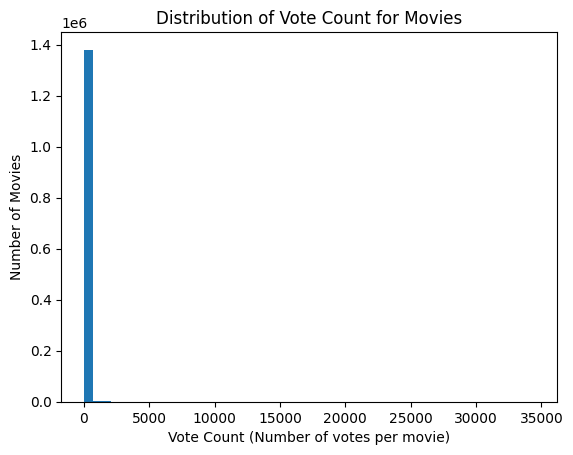

In [15]:
import matplotlib.pyplot as plt

plt.hist(df["vote_count"], bins=50)
plt.xlabel("Vote Count (Number of votes per movie)")
plt.ylabel("Number of Movies")
plt.title("Distribution of Vote Count for Movies")
plt.show()

In [16]:
(df["vote_count"] >= 20).sum()

np.int64(50430)

In [17]:
df = df[df["vote_count"] >= 85]

In [18]:
len(df)

20208

In [19]:
df["vote_count"].describe()

count    20208.000000
mean       948.669190
std       2196.199115
min         85.000000
25%        135.000000
50%        252.000000
75%        702.000000
max      34495.000000
Name: vote_count, dtype: float64

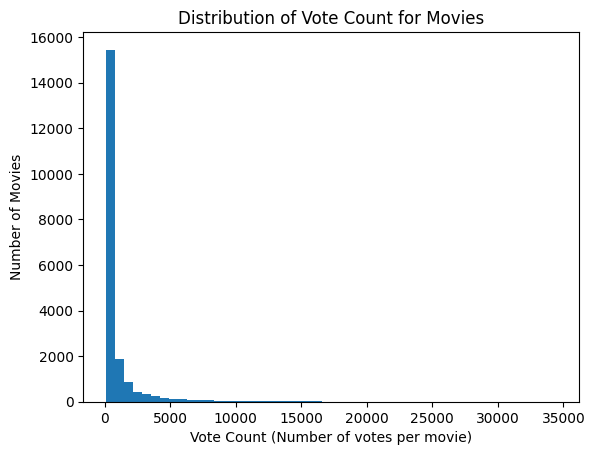

In [20]:
plt.hist(df["vote_count"], bins=50)
plt.xlabel("Vote Count (Number of votes per movie)")
plt.ylabel("Number of Movies")
plt.title("Distribution of Vote Count for Movies")
plt.show()

In [21]:
df["genres"] = df["genres"].str.lower()
df["keywords"] = df["keywords"].str.lower()
df["overview"] = df["overview"].str.lower()

In [22]:
df["tags"] = (
    df["genres"] + " " +
    df["keywords"] + " " +
    df["overview"]
)

In [23]:
df.head()

,title,genres,keywords,overview,vote_average,vote_count,tags
0,Inception,"action, science fiction, adventure","rescue, mission, dream, airplane, paris, franc...","cobb, a skilled thief who commits corporate es...",8.364,34495,"action, science fiction, adventure rescue, mis..."
1,Interstellar,"adventure, drama, science fiction","rescue, future, spacecraft, race against time,...",the adventures of a group of explorers who mak...,8.417,32571,"adventure, drama, science fiction rescue, futu..."
2,The Dark Knight,"drama, action, crime, thriller","joker, sadism, chaos, secret identity, crime f...",batman raises the stakes in his war on crime. ...,8.512,30619,"drama, action, crime, thriller joker, sadism, ..."
3,Avatar,"action, adventure, fantasy, science fiction","future, society, culture clash, space travel, ...","in the 22nd century, a paraplegic marine is di...",7.573,29815,"action, adventure, fantasy, science fiction fu..."
4,The Avengers,"science fiction, action, adventure","new york city, superhero, shield, based on com...",when an unexpected enemy emerges and threatens...,7.710,29166,"science fiction, action, adventure new york ci..."


In [24]:
df.sort_values(by="vote_count", ascending=False)[["title","vote_count"]].head(50)

,title,vote_count
0,Inception,34495
1,Interstellar,32571
2,The Dark Knight,30619
3,Avatar,29815
4,The Avengers,29166
5,Deadpool,28894
6,Avengers: Infinity War,27713
7,Fight Club,27238
8,Guardians of the Galaxy,26638
9,Pulp Fiction,25893


In [25]:
df["tags"] = df["tags"].str.replace(r"\s+", " ", regex=True).str.strip()

In [26]:
df.to_csv("movies_cleaned.csv", index=False)